# Utilities

In [109]:
import os, math, glob, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K

# Clear and set memory growth
K.clear_session()
tf.random.set_seed(42)
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
print("TF ready, GPUs:", gpus)

TF ready, GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [110]:
import re
import os
import pandas as pd
import cv2
import random
import numpy as np
from tensorflow import keras
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm


In [111]:
import os

# Paths
audio_path = '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24'
video_path = '/home/heru/sonamyangchen/ravdess_emotion/Video_Speech_Actor_01-24'

# Step 1: Collect audio IDs and paths
audio_ids = set()
audio_files_map = {}  # maps core_id -> full path

for actor in sorted(os.listdir(audio_path)):
    actor_folder = os.path.join(audio_path, actor)
    if os.path.isdir(actor_folder):
        for f in sorted(os.listdir(actor_folder)):
            if f.lower().endswith('.wav'):
                core_id = '-'.join(f[:-4].split('-')[1:])  # skip first field (modality)
                audio_ids.add(core_id)
                audio_files_map[core_id] = os.path.join(actor_folder, f)

print("Total audio files:", len(audio_files_map))  # should be 1440

# Step 2: Collect video files that match the audio files
matched_videos = []
matched_audios = []

for actor in sorted(os.listdir(video_path)):
    actor_folder = os.path.join(video_path, actor)
    if os.path.isdir(actor_folder):
        for f in sorted(os.listdir(actor_folder)):
            if f.lower().endswith(('.mp4', '.avi')):
                core_id = '-'.join(f[:-4].split('-')[1:])  # skip modality
                if core_id in audio_ids:
                    matched_videos.append(os.path.join(actor_folder, f))
                    matched_audios.append(audio_files_map[core_id])
                    audio_ids.discard(core_id)   # SAFE remove

print("Total matched pairs:", len(matched_videos))  # expected: 1440
print("First 5 matched video files:", matched_videos[:5])
print("First 5 matched audio files:", matched_audios[:5])


Total audio files: 1440
Total matched pairs: 1440
First 5 matched video files: ['/home/heru/sonamyangchen/ravdess_emotion/Video_Speech_Actor_01-24/Actor_01/01-01-01-01-01-01-01.mp4', '/home/heru/sonamyangchen/ravdess_emotion/Video_Speech_Actor_01-24/Actor_01/01-01-01-01-01-02-01.mp4', '/home/heru/sonamyangchen/ravdess_emotion/Video_Speech_Actor_01-24/Actor_01/01-01-01-01-02-01-01.mp4', '/home/heru/sonamyangchen/ravdess_emotion/Video_Speech_Actor_01-24/Actor_01/01-01-01-01-02-02-01.mp4', '/home/heru/sonamyangchen/ravdess_emotion/Video_Speech_Actor_01-24/Actor_01/01-01-02-01-01-01-01.mp4']
First 5 matched audio files: ['/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-02-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-02-01-01.wav', '/home/heru/sonamyangchen/ravdess_emotion/Audio_Speech_Actors_0

In [112]:
import os
import shutil

# Destination folder for filtered videos
filtered_video_path = '/home/heru/sonamyangchen/ravdess_emotion/Filtered_Video_1440'
os.makedirs(filtered_video_path, exist_ok=True)

# Copy matched videos
for video_file in matched_videos:
    # Get just the filename
    filename = os.path.basename(video_file)
    # Destination path
    dest_path = os.path.join(filtered_video_path, filename)
    # Copy the file
    shutil.copy2(video_file, dest_path)

print(f"Filtered {len(matched_videos)} videos saved to {filtered_video_path}")


Filtered 1440 videos saved to /home/heru/sonamyangchen/ravdess_emotion/Filtered_Video_1440


In [113]:
import os

# Your filtered video folder
filtered_path = '/home/heru/sonamyangchen/ravdess_emotion/Filtered_Video_1440'

filenames = []
feats = []
labels = []
paths = []
intensity_list = []

# Dictionaries for emotion and intensity
emotions = {
    1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry',
    6: 'fear', 7: 'disgust', 8: 'surprise'
}
emotional_intensity = {1: 'normal', 2: 'strong'}

for dirpath, dirnames, files in os.walk(filtered_path):
    for name in files:
        if name.lower().endswith(('.mp4', '.avi')):
            try:
                filename = os.path.splitext(name)[0]  # remove extension
                parts = filename.split('-')

                # Validate correct number of parts
                if len(parts) != 7:
                    print(f"[Warning] Skipping unexpected filename format: {name}")
                    continue

                # Extract required information safely
                emotion_id = int(parts[2])
                intensity_id = int(parts[3])

                if emotion_id not in emotions or intensity_id not in emotional_intensity:
                    print(f"[Warning] Unknown label in: {name}")
                    continue

                label = emotions[emotion_id]
                intensity = emotional_intensity[intensity_id]

                filenames.append(filename)
                feats.append(parts[2:])
                labels.append(label)
                intensity_list.append(intensity)
                paths.append(os.path.join(dirpath, name))

            except Exception as e:
                print(f"[Error] Could not process {name}: {e}")

# Preview
print("Total collected video samples:", len(paths))
print("First 5 filenames:", filenames[:5])
print("First 5 paths:", paths[:5])
print("First 5 labels:", labels[:5])
print("First 5 intensity:", intensity_list[:5])
print("First 5 feats:", feats[:5])


Total collected video samples: 1440
First 5 filenames: ['01-01-08-02-01-02-11', '01-01-03-01-02-02-23', '01-01-07-01-01-02-04', '01-01-08-02-02-01-18', '01-01-06-01-01-02-03']
First 5 paths: ['/home/heru/sonamyangchen/ravdess_emotion/Filtered_Video_1440/01-01-08-02-01-02-11.mp4', '/home/heru/sonamyangchen/ravdess_emotion/Filtered_Video_1440/01-01-03-01-02-02-23.mp4', '/home/heru/sonamyangchen/ravdess_emotion/Filtered_Video_1440/01-01-07-01-01-02-04.mp4', '/home/heru/sonamyangchen/ravdess_emotion/Filtered_Video_1440/01-01-08-02-02-01-18.mp4', '/home/heru/sonamyangchen/ravdess_emotion/Filtered_Video_1440/01-01-06-01-01-02-03.mp4']
First 5 labels: ['surprise', 'happy', 'disgust', 'surprise', 'fear']
First 5 intensity: ['strong', 'normal', 'normal', 'strong', 'normal']
First 5 feats: [['08', '02', '01', '02', '11'], ['03', '01', '02', '02', '23'], ['07', '01', '01', '02', '04'], ['08', '02', '02', '01', '18'], ['06', '01', '01', '02', '03']]


# Data Exploration

In [114]:
import pandas as pd

# Create DataFrame from feats
df = pd.DataFrame(feats, columns=['emotion', 'emotional intensity', 'statement', 'repetition', 'actor']).astype(int)

# Map numeric codes to labels
df['emotion'] = df['emotion'].map(emotions)
df['emotional intensity'] = df['emotional intensity'].map(emotional_intensity)

# Set filenames as index
df['index'] = filenames
df.set_index('index', inplace=True)

# Optional: add full file path
df['path'] = paths

# Display
df.head()


,emotion,emotional intensity,statement,repetition,actor,path
index,,,,,,
01-01-08-02-01-02-11,surprise,strong,1,2,11,/home/heru/sonamyangchen/ravdess_emotion/Filte...
01-01-03-01-02-02-23,happy,normal,2,2,23,/home/heru/sonamyangchen/ravdess_emotion/Filte...
01-01-07-01-01-02-04,disgust,normal,1,2,4,/home/heru/sonamyangchen/ravdess_emotion/Filte...
01-01-08-02-02-01-18,surprise,strong,2,1,18,/home/heru/sonamyangchen/ravdess_emotion/Filte...
01-01-06-01-01-02-03,fear,normal,1,2,3,/home/heru/sonamyangchen/ravdess_emotion/Filte...


# Export frames
one frame every skip=3 starting from the 21th frame
proportional resize to obtain height=224
saved as png with and name videoname_iframe

In [115]:
import os
import cv2

# Base folder to save all extracted frames
dataset_base = '/home/heru/sonamyangchen/ravdess_emotion/Datasets/Video_Frames_Extracted'

def prepare_all_videos(filenames, paths, skip=1):
    for count, (filename, video_path) in enumerate(zip(filenames, paths)):
        # Build output frame directory inside the Datasets folder
        output_path = os.path.join(dataset_base, filename)

        save_frames(filename, video_path, output_path, skip)
        print(f"Processed video {count+1}/{len(paths)}")

def save_frames(filename, input_path, output_path, skip):
    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        print(f"[ERROR] Could not open video: {input_path}")
        return

    # Ensure output folder exists
    os.makedirs(output_path, exist_ok=True)

    count = 0
    saved = 0

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break  # Stop when video ends

            # Skip first 20 frames, save every "skip" frame
            if count > 20 and (count % skip == 0):
                try:
                    frame = cv2.resize(frame, (224, 224))
                    save_name = os.path.join(output_path, f"{filename}_{count}.png")
                    cv2.imwrite(save_name, frame)
                    saved += 1
                except Exception as e:
                    print(f"[ERROR] Could not save frame at count {count}: {e}")

            count += 1

    except Exception as e:
        print(f"[ERROR] Crash occurred while processing {filename}: {e}")

    finally:
        cap.release()

    print(f"✔ Saved {saved} frames for {filename}")


In [116]:
prepare_all_videos(filenames, paths, skip=3)

✔ Saved 24 frames for 01-01-08-02-01-02-11
Processed video 1/1440
✔ Saved 26 frames for 01-01-03-01-02-02-23
Processed video 2/1440
✔ Saved 32 frames for 01-01-07-01-01-02-04
Processed video 3/1440
✔ Saved 32 frames for 01-01-08-02-02-01-18
Processed video 4/1440
✔ Saved 32 frames for 01-01-06-01-01-02-03
Processed video 5/1440
✔ Saved 31 frames for 01-01-05-01-02-02-20
Processed video 6/1440
✔ Saved 30 frames for 01-01-06-02-01-02-02
Processed video 7/1440
✔ Saved 31 frames for 01-01-08-01-01-01-05
Processed video 8/1440
✔ Saved 36 frames for 01-01-07-01-01-01-18
Processed video 9/1440
✔ Saved 31 frames for 01-01-03-02-02-02-04
Processed video 10/1440
✔ Saved 30 frames for 01-01-02-01-01-01-14
Processed video 11/1440
✔ Saved 27 frames for 01-01-03-01-02-02-10
Processed video 12/1440
✔ Saved 37 frames for 01-01-05-02-02-02-01
Processed video 13/1440
✔ Saved 28 frames for 01-01-01-01-01-01-14
Processed video 14/1440
✔ Saved 26 frames for 01-01-04-01-01-01-05
Processed video 15/1440
✔ Sa

# 224x224 black background

In [117]:
import os
import cv2

# Base folder to save black-background frames
dataset_base = '/home/heru/sonamyangchen/ravdess_emotion/Datasets/Video_Frames_Black'

def prepare_all_videos(filenames, paths, skip=3):
    for count, (filename, video_path) in enumerate(zip(filenames, paths)):
        try:
            # Create output path inside Datasets folder
            output_path = os.path.join(dataset_base, filename)
            save_frames(filename, video_path, output_path, skip)
            print(f"✅ Processed video {count+1}/{len(paths)}")
        except Exception as e:
            print(f"❌ Error processing {video_path}: {e}")

def save_frames(filename, input_path, output_path, skip):
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        print(f"⚠ Could not open video: {input_path}")
        return

    os.makedirs(output_path, exist_ok=True)
    count = 0
    saved = 0

    try:
        while True:
            ret, frame = cap.read()
            if not ret or frame is None:
                break

            if count > 20 and count % skip == 0:
                h, w = frame.shape[:2]
                if h < 224 or w < 224:
                    print(f"⚠ Frame too small ({w}x{h}) — skipping")
                    count += 1
                    continue

                # Convert to grayscale safely
                try:
                    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                except Exception as e:
                    print(f"⚠ Could not convert frame {count} to gray: {e}")
                    count += 1
                    continue

                # Black background
                _, thresh = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY)
                frame[thresh == 255] = 0

                # Resize to 398x224
                frame = cv2.resize(frame, (398, 224))

                # Center crop to 224x224
                crop_x = (frame.shape[1] - 224) // 2
                frame = frame[:, crop_x: crop_x + 224]

                # Save frame
                save_path = os.path.join(output_path, f"{filename}_{count}.png")
                cv2.imwrite(save_path, frame)
                saved += 1

            count += 1

    finally:
        cap.release()

    print(f"✔ Saved {saved} frames for {filename}")


In [118]:
prepare_all_videos(filenames, paths, skip=3)

✔ Saved 24 frames for 01-01-08-02-01-02-11
✅ Processed video 1/1440
✔ Saved 26 frames for 01-01-03-01-02-02-23
✅ Processed video 2/1440
✔ Saved 32 frames for 01-01-07-01-01-02-04
✅ Processed video 3/1440
✔ Saved 32 frames for 01-01-08-02-02-01-18
✅ Processed video 4/1440
✔ Saved 32 frames for 01-01-06-01-01-02-03
✅ Processed video 5/1440
✔ Saved 31 frames for 01-01-05-01-02-02-20
✅ Processed video 6/1440
✔ Saved 30 frames for 01-01-06-02-01-02-02
✅ Processed video 7/1440
✔ Saved 31 frames for 01-01-08-01-01-01-05
✅ Processed video 8/1440
✔ Saved 36 frames for 01-01-07-01-01-01-18
✅ Processed video 9/1440
✔ Saved 31 frames for 01-01-03-02-02-02-04
✅ Processed video 10/1440
✔ Saved 30 frames for 01-01-02-01-01-01-14
✅ Processed video 11/1440
✔ Saved 27 frames for 01-01-03-01-02-02-10
✅ Processed video 12/1440
✔ Saved 37 frames for 01-01-05-02-02-02-01
✅ Processed video 13/1440
✔ Saved 28 frames for 01-01-01-01-01-01-14
✅ Processed video 14/1440
✔ Saved 26 frames for 01-01-04-01-01-01-05


# 224x224 only faces BW

In [119]:
import os
import cv2

def prepare_all_videos(filenames, paths, skip=3):
    base_output_dir = '/home/heru/sonamyangchen/ravdess_emotion/Datasets/Video_Frames_Face_BW'
    os.makedirs(base_output_dir, exist_ok=True)

    total_videos = len(filenames)

    for count, (filename, video_path) in enumerate(zip(filenames, paths), 1):
        try:
            # Create per-video output folder
            output_path = os.path.join(base_output_dir, filename)
            save_frames(filename, video_path, output_path, skip)
            print(f"✅ Processed video {count}/{total_videos}: {filename}")

        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")

def save_frames(filename, input_path, output_path, skip):
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        print(f"⚠ Cannot open video: {input_path}. Skipping.")
        return

    # Haar cascade from OpenCV built-in path
    haar_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    if haar_cascade.empty():
        print(f"⚠ Haar cascade not loaded properly. Skipping {filename}.")
        return

    os.makedirs(output_path, exist_ok=True)
    count, saved = 0, 0

    while True:
        ret, frame = cap.read()
        if not ret or frame is None:
            break

        if count > 20 and count % skip == 0:
            try:
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

                faces = haar_cascade.detectMultiScale(gray, scaleFactor=1.12, minNeighbors=9)
                if len(faces) == 0:
                    faces = haar_cascade.detectMultiScale(gray, scaleFactor=1.02, minNeighbors=9)

                if len(faces) == 0:
                    count += 1
                    continue

                if len(faces) > 1:
                    areas = [w*h for (x, y, w, h) in faces]
                    faces = [faces[areas.index(max(areas))]]

                for (x, y, w, h) in faces:
                    face = gray[y:y+h, x:x+w]
                    if face.shape[0] < 50 or face.shape[1] < 50:
                        continue
                    face_resized = cv2.resize(face, (224, 224))
                    save_path = os.path.join(output_path, f'{filename}_{count}.png')
                    cv2.imwrite(save_path, face_resized)
                    saved += 1

            except Exception as e:
                print(f"⚠ Error processing frame {count} in {filename}: {e}")

        count += 1

    cap.release()
    print(f"✔ Saved {saved} face frames for {filename}")




In [120]:
# Call the function for your dataset
prepare_all_videos(filenames, paths, skip=3)


✔ Saved 24 face frames for 01-01-08-02-01-02-11
✅ Processed video 1/1440: 01-01-08-02-01-02-11
✔ Saved 26 face frames for 01-01-03-01-02-02-23
✅ Processed video 2/1440: 01-01-03-01-02-02-23
✔ Saved 32 face frames for 01-01-07-01-01-02-04
✅ Processed video 3/1440: 01-01-07-01-01-02-04
✔ Saved 32 face frames for 01-01-08-02-02-01-18
✅ Processed video 4/1440: 01-01-08-02-02-01-18
✔ Saved 32 face frames for 01-01-06-01-01-02-03
✅ Processed video 5/1440: 01-01-06-01-01-02-03
✔ Saved 31 face frames for 01-01-05-01-02-02-20
✅ Processed video 6/1440: 01-01-05-01-02-02-20
✔ Saved 30 face frames for 01-01-06-02-01-02-02
✅ Processed video 7/1440: 01-01-06-02-01-02-02
✔ Saved 31 face frames for 01-01-08-01-01-01-05
✅ Processed video 8/1440: 01-01-08-01-01-01-05
✔ Saved 36 face frames for 01-01-07-01-01-01-18
✅ Processed video 9/1440: 01-01-07-01-01-01-18
✔ Saved 31 face frames for 01-01-03-02-02-02-04
✅ Processed video 10/1440: 01-01-03-02-02-02-04
✔ Saved 30 face frames for 01-01-02-01-01-01-14
✅

# Mean face

In [121]:
import os

# Map RAVDESS emotion labels to match audio stream labels
emotions_tras = {1: 1, 2: 4, 3: 5, 4: 0, 5: 3, 6: 2, 7: 6}  
emotions = {0: 'angry', 1: 'calm', 2: 'disgust', 3: 'fear', 4: 'happy', 5: 'sad', 6: 'surprise'}

# Dataset path
path_frames_face_BW = "/home/heru/sonamyangchen/ravdess_emotion/Datasets/Video_Frames_Face_BW/"

# Actor IDs for validation and testing
val_actors = ['19', '20']
test_actors = ['21', '22', '23', '24']

# Dataset lists
filenames_train = []
filenames_val = []

# Walk through dataset
for dirpath, dirnames, files in os.walk(path_frames_face_BW):
    if not files:
        continue

    # Filter only image files
    image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if len(image_files) == 0:
        continue

    # Extract emotion label from the first file
    try:
        class_temp = int(image_files[0].split('-')[2]) - 1
    except:
        print(f"⚠ Skipping folder {dirpath}, unexpected file naming.")
        continue

    if class_temp == 0:
        continue  # skip neutral

    # Extract actor ID (last number in folder name)
    folder_name = os.path.basename(dirpath)
    actor_id = folder_name.split('-')[-1]

    # Full paths to frames
    frame_paths = [os.path.join(dirpath, f) for f in image_files]
    labels = [emotions_tras[class_temp]] * len(frame_paths)

    # Assign to train or validation
    if actor_id in val_actors:
        filenames_val.append(list(zip(frame_paths, labels)))
    elif actor_id not in val_actors + test_actors:
        filenames_train.append(list(zip(frame_paths, labels)))
    # test actors ignored for now

# Sanity check
print(f"Total training videos: {len(filenames_train)}")
print(f"Total validation videos: {len(filenames_val)}")
if filenames_train:
    print(f"Example training frames: {filenames_train[0][:5]}")
if filenames_val:
    print(f"Example validation frames: {filenames_val[0][:5]}")


Total training videos: 1008
Total validation videos: 112
Example training frames: [('/home/heru/sonamyangchen/ravdess_emotion/Datasets/Video_Frames_Face_BW/01-01-02-02-01-02-01/01-01-02-02-01-02-01_111.png', 1), ('/home/heru/sonamyangchen/ravdess_emotion/Datasets/Video_Frames_Face_BW/01-01-02-02-01-02-01/01-01-02-02-01-02-01_42.png', 1), ('/home/heru/sonamyangchen/ravdess_emotion/Datasets/Video_Frames_Face_BW/01-01-02-02-01-02-01/01-01-02-02-01-02-01_99.png', 1), ('/home/heru/sonamyangchen/ravdess_emotion/Datasets/Video_Frames_Face_BW/01-01-02-02-01-02-01/01-01-02-02-01-02-01_93.png', 1), ('/home/heru/sonamyangchen/ravdess_emotion/Datasets/Video_Frames_Face_BW/01-01-02-02-01-02-01/01-01-02-02-01-02-01_24.png', 1)]
Example validation frames: [('/home/heru/sonamyangchen/ravdess_emotion/Datasets/Video_Frames_Face_BW/01-01-07-01-02-02-19/01-01-07-01-02-02-19_42.png', 2), ('/home/heru/sonamyangchen/ravdess_emotion/Datasets/Video_Frames_Face_BW/01-01-07-01-02-02-19/01-01-07-01-02-02-19_60.pn

In [122]:
import os
import random
import cv2
import numpy as np
from tqdm import tqdm

def sampling(list_of_videos, num_frames_desired):
    """
    Randomly sample 'num_frames_desired' frames from each video list.
    """
    tot = []
    for elem in list_of_videos:
        if len(elem) >= num_frames_desired:
            sampled_list = random.sample(elem, num_frames_desired)
        else:
            # If a video has fewer frames than desired, take all frames
            sampled_list = elem
        tot += sampled_list
    return tot

def compute_mean_face(filenames_train, save_path='Datasets/mean_face.npy', frame_size=(112,112)):
    """
    Compute the mean face over the sampled frames in the training dataset.
    """
    # Determine the minimum number of frames per video for balanced sampling
    frames_per_vid = min([len(elem) for elem in filenames_train])
    print("Frames per video for balanced sampling:", frames_per_vid)

    # Sample frames
    filenames_sampled = sampling(filenames_train, frames_per_vid)
    random.shuffle(filenames_sampled)

    faces = []

    for path, label in tqdm(filenames_sampled, desc="Processing frames"):
        try:
            face = cv2.imread(path)
            if face is None:
                continue  # skip if image is not readable

            # Resize and convert to grayscale
            face = cv2.resize(face, frame_size)
            face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
            faces.append(face)

        except Exception as e:
            print(f"⚠ Error processing frame {path}: {e}")

    if len(faces) == 0:
        print("⚠ No faces found to compute mean face.")
        return None

    faces = np.array(faces, dtype=np.float32)
    mean_face = np.mean(faces, axis=0)
    mean_face /= 255.0  # normalize to [0,1]
    mean_face = np.expand_dims(mean_face, axis=2)  # add channel dimension

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    np.save(save_path, mean_face)
    print(f"✔ Mean face saved at {save_path}")

    return mean_face


In [123]:
mean_face = compute_mean_face(filenames_train, save_path='Datasets/mean_face.npy', frame_size=(112,112))


Frames per video for balanced sampling: 23


Processing frames: 100%|██████████| 23184/23184 [00:09<00:00, 2509.27it/s]


✔ Mean face saved at Datasets/mean_face.npy


StreamVideo_FaceOnly

Video stream train

# Video stream train

In [124]:
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
import os
import random
from datetime import datetime

import tensorflow as tf

# Keras module and tools
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from keras.layers import Input, Flatten, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dense, Dropout
from keras.layers import RandomFlip, CenterCrop, RandomZoom
from keras.metrics import sparse_categorical_accuracy, sparse_top_k_categorical_accuracy
from keras.losses import sparse_categorical_crossentropy
from keras.models import Model, Sequential
from keras.optimizers import Adam
from keras.applications import ResNet50
from keras_cv.layers import RandomCutout
import keras_tuner

In [125]:
if tf.test.gpu_device_name(): 
    print('Default GPU Device:{}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF")

Default GPU Device:/device:GPU:0


I0000 00:00:1763699179.272898    1799 gpu_device.cc:2019] Created device /device:GPU:0 with 13709 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1763699179.276444    1799 gpu_device.cc:2019] Created device /device:GPU:0 with 13709 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:01:00.0, compute capability: 8.6


In [126]:
emotions_tras = {1:1, 2:4, 3:5, 4:0, 5:3, 6:2, 7:6}  # to match audio stream labels
emotions = {0:'angry', 1:'calm', 2:'disgust', 3:'fear', 4:'happy', 5:'sad', 6:'surprise'}

# Corrected dataset paths
path_frames = "Datasets/"
path_frames_black = "Datasets/Video_Frames_Black/"

height_orig = 224
width_orig = 224
width_orig_full = 398
height_targ = 112
width_targ = 112

batch_size = 64
num_classes = len(emotions)

val_actors = ['19', '20']
test_actors = ['21', '22', '23', '24']


# Model 1: 224x224 color
Dataset creation

In [127]:
filenames_train = []  # train
filenames_val = []    # validation

for dirpath, dirnames, files in os.walk(path_frames):
    # Skip empty directories
    if not files:
        continue

    # Filter only .png or .jpg files (ignore hidden/system files)
    files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not files:
        continue

    # Try to extract emotion label from the first file
    try:
        parts = files[0].split('-')
        if len(parts) < 3:
            print(f"⚠ Skipping {dirpath}, unexpected file name: {files[0]}")
            continue
        class_temp = int(parts[2]) - 1
    except ValueError:
        print(f"⚠ Skipping {dirpath}, cannot parse label from: {files[0]}")
        continue

    # Exclude 'neutral' label
    if class_temp == 0:
        continue

    # Full paths for all frames
    frame_paths = [os.path.join(dirpath, f) for f in files]
    labels = [emotions_tras[class_temp]] * len(files)

    # Assign to train or validation depending on actor ID in folder path
    if any(act in dirpath for act in val_actors):
        filenames_val.append(list(zip(frame_paths, labels)))
    elif any(act in dirpath for act in test_actors):
        continue  # skip test actors
    else:
        filenames_train.append(list(zip(frame_paths, labels)))

print(f"Total training videos: {len(filenames_train)}")
print(f"Total validation videos: {len(filenames_val)}")


Total training videos: 3024
Total validation videos: 336


In [128]:
def sampling(list, num_frames_desired):
    tot = []
    for elem in list:
        sampled_list = random.sample(elem, num_frames_desired)
        tot += sampled_list
    return(tot)

def parse_image(filename):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.convert_image_dtype(image, dtype=tf.float16)
    image = tf.image.resize(image, [height_orig, width_orig_full])
    print('shape frames:', image.shape)
    return image

def configure_for_performance(ds):
    ds = ds.shuffle(buffer_size=1000) # serve?
    ds = ds.batch(batch_size)
    ds = ds.repeat()
    ds = ds.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return ds

def load_dataset(filenames, batch_size):
    frames_per_vid = min([len(elem) for elem in filenames])     # number of frames per clip in order to have balanced classes
    print("frames per video:", frames_per_vid) 

    filenames_sampled = sampling(filenames, frames_per_vid)
    random.shuffle(filenames_sampled)

    zipped = [list(t) for t in zip(*filenames_sampled)]

    names = zipped[0]
    labels = zipped[1]

    names = tf.data.Dataset.from_tensor_slices(names)
    images = names.map(parse_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)

    labels = [elem for elem in labels]
    labels = tf.data.Dataset.from_tensor_slices(labels)

    ds = tf.data.Dataset.zip((images, labels))
    ds = configure_for_performance(ds)

    frame_number = len(filenames_sampled)
    step_per_epoch = frame_number // batch_size
    print('frames number:', frame_number, '\nbatch size:', batch_size, '\nbatch number:', step_per_epoch)
    return ds, step_per_epoch

In [129]:
train_ds, step_per_epoch_train = load_dataset(filenames_train, batch_size)

frames per video: 23
shape frames: (224, 398, 3)
frames number: 69552 
batch size: 64 
batch number: 1086


In [130]:
val_ds, step_per_epoch_val = load_dataset(filenames_val, batch_size)

frames per video: 24
shape frames: (224, 398, 3)
frames number: 8064 
batch size: 64 
batch number: 126


# Augmentation

In [131]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    CenterCrop(height_orig, width_orig),
    RandomZoom(height_factor=(-0.2, 0.2))
    ])

(224, 398, 3)


(np.float64(-0.5), np.float64(397.5), np.float64(223.5), np.float64(-0.5))

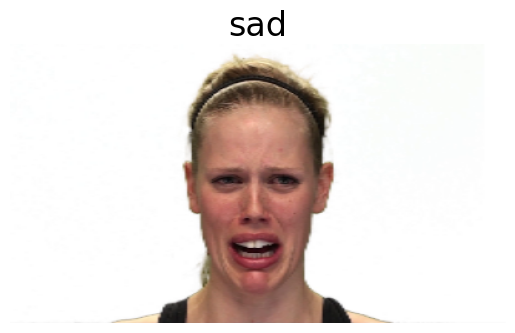

In [132]:
examples = train_ds.unbatch().take(1)

for elem in examples:
    print(elem[0].shape)

o = elem[0]
plt.imshow(o)
plt.title(emotions[int(elem[1])], fontdict={'fontsize': 24})
plt.axis('off')

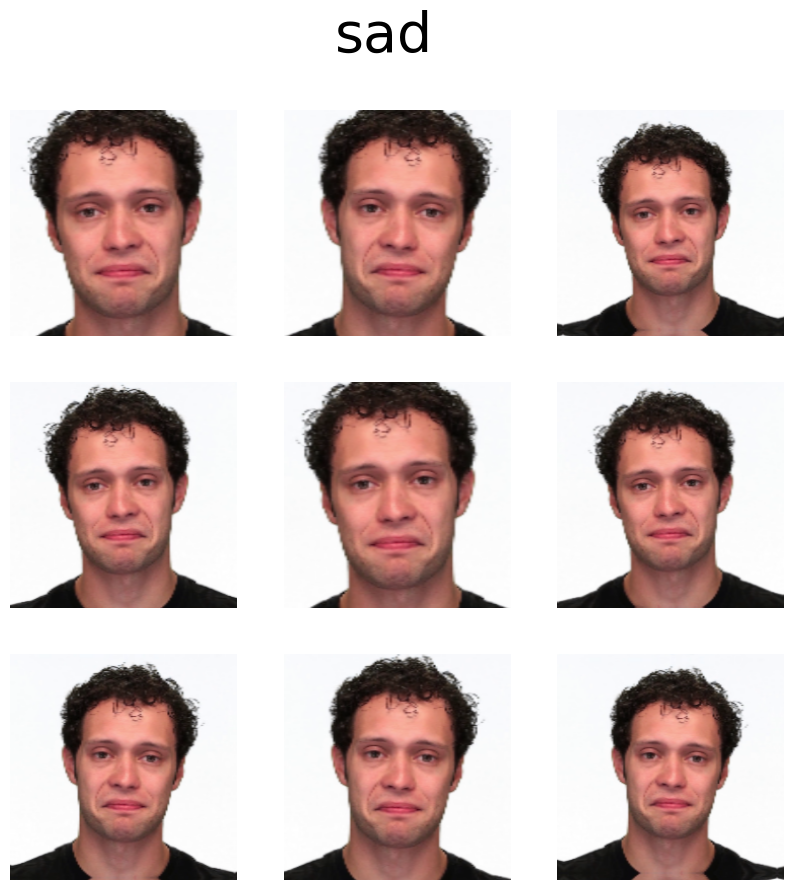

In [133]:
for images, labels in train_ds.take(1):
    fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
    fig.suptitle(emotions[int(labels[0])], fontsize=40)
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0), training=True
        )
        plt.imshow(augmented_image[0], cmap='gray')
        plt.axis("off")

# Net Architecture

In [134]:
import os

models_path = "/home/heru/sonamyangchen/ravdess_emotion/Video_model/"

if not os.path.exists(models_path):
    os.makedirs(models_path)
    print("Directory created:", models_path)
else:
    print("Directory already exists:", models_path)


Directory already exists: /home/heru/sonamyangchen/ravdess_emotion/Video_model/


In [135]:
# frame_type = ''
epochs = 10
lr = 0.001
momentum = 0.5

In [136]:
from datetime import datetime
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Correct path to save model with timestamp and file prefix
checkpoint_filepath = (
    f'/home/heru/sonamyangchen/ravdess_emotion/Video_model/'
    f'Video-CNN_model_{datetime.now().strftime("%d-%m-%y_%H-%M")}_face.keras'
)

# Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor="val_sparse_categorical_accuracy",
    factor=0.5,
    patience=2,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_sparse_categorical_accuracy",
    patience=4,
    verbose=1,
    restore_best_weights=True
)

save_best = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_sparse_categorical_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

print("Checkpoint will be saved to:", checkpoint_filepath)


Checkpoint will be saved to: /home/heru/sonamyangchen/ravdess_emotion/Video_model/Video-CNN_model_21-11-25_10-27_face.keras


In [137]:
pretrained_model = ResNet50(include_top=False,
                            input_shape=(height_orig, width_orig, 3),
                            weights='imagenet',
                            pooling='avg')
pretrained_model.trainable = False


input = Input(shape=(height_orig, width_orig_full, 3))
x = input
x = data_augmentation(x)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = pretrained_model(x, training=False) # `training=False` important for fine-tuning
x = Dense(512, activation='relu')(x)
x = Dense(num_classes, activation='softmax')(x)
output = x

net_1 = Model(input, output)
net_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 398,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      3,591 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,640,391 (94.00 MB)

 Trainable params: 1,052,679 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [138]:
net_1.compile(
    optimizer=Adam(learning_rate=lr),
    # optimizer=keras.optimizers.SGD(learning_rate=learningrate, momentum=momentum)
    loss=sparse_categorical_crossentropy,
    metrics=[sparse_categorical_accuracy, sparse_top_k_categorical_accuracy],
)

# Training

In [139]:
history_1 = net_1.fit(train_ds,
                    epochs=epochs,
                    validation_data=val_ds,
                    batch_size=batch_size,
                    steps_per_epoch=step_per_epoch_train,
                    validation_steps=step_per_epoch_val,
                    # callbacks=[reduce_lr, early_stop, save_best],
                    # callbacks=[save_best],
                    verbose=1)

Epoch 1/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 1.9712 - sparse_categorical_accuracy: 0.1553 - sparse_top_k_categorical_accuracy: 0.7281

2025-11-21 10:30:30.410231: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 68468992 bytes after encountering the first element of size 68468992 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1086/1086 ━━━━━━━━━━━━━━━━━━━━ 157s 141ms/step - loss: 1.9711 - sparse_categorical_accuracy: 0.1553 - sparse_top_k_categorical_accuracy: 0.7282 - val_loss: 1.9474 - val_sparse_categorical_accuracy: 0.1683 - val_sparse_top_k_categorical_accuracy: 0.7091
Epoch 2/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 1.9280 - sparse_categorical_accuracy: 0.1781 - sparse_top_k_categorical_accuracy: 0.7646

2025-11-21 10:33:05.498818: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 68468992 bytes after encountering the first element of size 68468992 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1086/1086 ━━━━━━━━━━━━━━━━━━━━ 155s 143ms/step - loss: 1.9280 - sparse_categorical_accuracy: 0.1781 - sparse_top_k_categorical_accuracy: 0.7646 - val_loss: 1.9409 - val_sparse_categorical_accuracy: 0.1429 - val_sparse_top_k_categorical_accuracy: 0.7356
Epoch 3/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 1.8955 - sparse_categorical_accuracy: 0.1981 - sparse_top_k_categorical_accuracy: 0.8026

...

1086/1086 ━━━━━━━━━━━━━━━━━━━━ 156s 144ms/step - loss: 1.8955 - sparse_categorical_accuracy: 0.1981 - sparse_top_k_categorical_accuracy: 0.8026 - val_loss: 1.9699 - val_sparse_categorical_accuracy: 0.1512 - val_sparse_top_k_categorical_accuracy: 0.7465
Epoch 4/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 1.8786 - sparse_categorical_accuracy: 0.2069 - sparse_top_k_categorical_accuracy: 0.8162

2025-11-21 10:38:16.206327: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 68468992 bytes after encountering the first element of size 68468992 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1086/1086 ━━━━━━━━━━━━━━━━━━━━ 155s 143ms/step - loss: 1.8786 - sparse_categorical_accuracy: 0.2069 - sparse_top_k_categorical_accuracy: 0.8162 - val_loss: 2.0400 - val_sparse_categorical_accuracy: 0.1659 - val_sparse_top_k_categorical_accuracy: 0.7707
Epoch 5/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 1.8596 - sparse_categorical_accuracy: 0.2156 - sparse_top_k_categorical_accuracy: 0.8302

2025-11-21 10:40:51.875925: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 68468992 bytes after encountering the first element of size 68468992 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1086/1086 ━━━━━━━━━━━━━━━━━━━━ 156s 143ms/step - loss: 1.8595 - sparse_categorical_accuracy: 0.2156 - sparse_top_k_categorical_accuracy: 0.8302 - val_loss: 2.0063 - val_sparse_categorical_accuracy: 0.1507 - val_sparse_top_k_categorical_accuracy: 0.7613
Epoch 6/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 155s 142ms/step - loss: 1.8462 - sparse_categorical_accuracy: 0.2281 - sparse_top_k_categorical_accuracy: 0.8376 - val_loss: 2.0506 - val_sparse_categorical_accuracy: 0.1720 - val_sparse_top_k_categorical_accuracy: 0.7904
Epoch 7/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 155s 143ms/step - loss: 1.8318 - sparse_categorical_accuracy: 0.2388 - sparse_top_k_categorical_accuracy: 0.8474 - val_loss: 2.1875 - val_sparse_categorical_accuracy: 0.1766 - val_sparse_top_k_categorical_accuracy: 0.7716
Epoch 8/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 156s 144ms/step - loss: 1.8210 - sparse_categorical_accuracy: 0.2463 - sparse_top_k_categorical_accuracy: 0.8524 - val_loss: 2.0816 - val_sparse_categorical_accuracy: 0.1813 - v

# Evaluation

In [140]:
net_1.evaluate(val_ds,
            batch_size=batch_size,
            steps=step_per_epoch_val) 

126/126 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - loss: 2.0702 - sparse_categorical_accuracy: 0.1865 - sparse_top_k_categorical_accuracy: 0.8055


[2.059922933578491, 0.1873759925365448, 0.805059552192688]

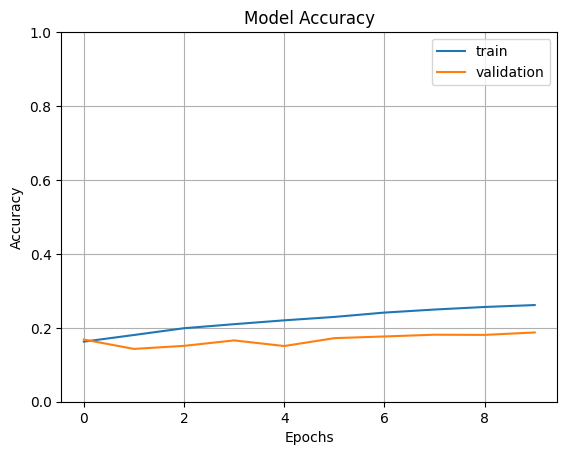

In [141]:
fig1 = plt.gcf()
plt.plot(history_1.history['sparse_categorical_accuracy'])
plt.plot(history_1.history['val_sparse_categorical_accuracy'])
plt.axis(ymin=0, ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
# plt.savefig('Plots/model1_accuracy.png')
plt.show()

In [142]:
from sklearn.metrics import classification_report
y_val = []
y_pred = []
i = 1
for image, target in val_ds:
  if i > step_per_epoch_val:
    break
  y_val.extend(target.numpy())
  y_pred.extend(net_1(image, training=False).numpy().argmax(axis=1))
  i+=1

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.16      0.06      0.09      1152
           1       0.20      0.53      0.29      1152
           2       0.20      0.36      0.25      1152
           3       0.13      0.04      0.06      1152
           4       0.18      0.26      0.21      1152
           5       0.07      0.02      0.03      1152
           6       0.25      0.04      0.07      1152

    accuracy                           0.19      8064
   macro avg       0.17      0.19      0.14      8064
weighted avg       0.17      0.19      0.14      8064



In [147]:
# Directory to save models
save_dir = '/home/heru/sonamyangchen/ravdess_emotion/Video_model/'
os.makedirs(save_dir, exist_ok=True)

# Function to save model with timestamp
def save_model(model, prefix="Video-CNN_model"):
    timestamp = datetime.now().strftime("%d-%m-%y_%H-%M-%S")
    filepath = os.path.join(save_dir, f"{prefix}_{timestamp}_face.keras")
    model.save(filepath)
    print(f"Model saved to: {filepath}")
    return filepath
# Save the trained model
save_model(net_1, prefix="Video-CNN_model1")

Model saved to: /home/heru/sonamyangchen/ravdess_emotion/Video_model/Video-CNN_model1_21-11-25_11-04-00_face.keras


'/home/heru/sonamyangchen/ravdess_emotion/Video_model/Video-CNN_model1_21-11-25_11-04-00_face.keras'

# Model 2: 224x224 black background
Dataset creation

In [148]:
filenames_train = [] # train
filenames_val = [] # validation

for (dirpath, dirnames, fn) in os.walk(path_frames_black):
    if fn != []:
        class_temp = int(fn[0].split('-')[2]) - 1
        if class_temp != 0:                                                     # exclude 'neutral' label
            if any(act in dirpath for act in (test_actors+val_actors))==False:  # select only train actors
                path = [os.path.join(dirpath, elem) for elem in fn]
                label = [emotions_tras[class_temp]] * len(fn)                   # emotion transposition
                filenames_train.append(list(zip(path, label)))
            
            if any(act in dirpath for act in val_actors):                       # select only validation actors
                path = [os.path.join(dirpath, elem) for elem in fn]
                label = [emotions_tras[class_temp]] * len(fn)
                filenames_val.append(list(zip(path, label)))

In [149]:
def sampling(list, num_frames_desired):
    tot = []
    for elem in list:
        sampled_list = random.sample(elem, num_frames_desired)
        tot += sampled_list
    return(tot)

def parse_image(filename):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.convert_image_dtype(image, dtype=tf.float16)
    image = tf.image.resize(image, [height_orig, width_orig])
    print('shape frames:', image.shape)
    return image

def configure_for_performance(ds):
    ds = ds.shuffle(buffer_size=1000) # serve?
    ds = ds.batch(batch_size)
    ds = ds.repeat()
    ds = ds.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return ds

def load_dataset(filenames, batch_size):
    frames_per_vid = min([len(elem) for elem in filenames])     # number of frames per clip in order to have balanced classes
    print("frames per video:", frames_per_vid) 

    filenames_sampled = sampling(filenames, frames_per_vid)
    random.shuffle(filenames_sampled)

    zipped = [list(t) for t in zip(*filenames_sampled)]

    names = zipped[0]
    labels = zipped[1]

    names = tf.data.Dataset.from_tensor_slices(names)
    images = names.map(parse_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)

    labels = [elem for elem in labels]
    labels = tf.data.Dataset.from_tensor_slices(labels)

    ds = tf.data.Dataset.zip((images, labels))
    ds = configure_for_performance(ds)

    frame_number = len(filenames_sampled)
    step_per_epoch = frame_number // batch_size
    print('frames number:', frame_number, '\nbatch size:', batch_size, '\nbatch number:', step_per_epoch)
    return ds, step_per_epoch

In [150]:
train_ds, step_per_epoch_train = load_dataset(filenames_train, batch_size)

frames per video: 23
shape frames: (224, 224, 3)
frames number: 23184 
batch size: 64 
batch number: 362


In [151]:
val_ds, step_per_epoch_val = load_dataset(filenames_val, batch_size)

frames per video: 24
shape frames: (224, 224, 3)
frames number: 2688 
batch size: 64 
batch number: 42


# Augmentation

In [152]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomZoom(height_factor=(-0.2, 0.2))
])

(224, 224, 3)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

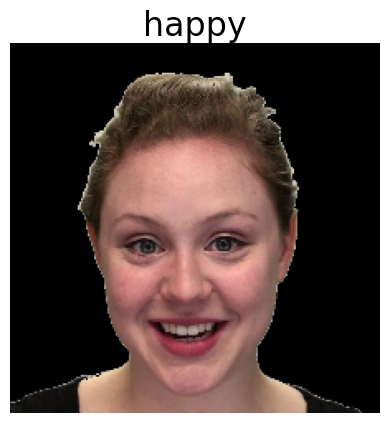

In [153]:
examples = train_ds.unbatch().take(1)

for elem in examples:
    print(elem[0].shape)
plt.imshow(elem[0])
plt.title(emotions[int(elem[1])], fontdict={'fontsize': 24})
plt.axis('off')

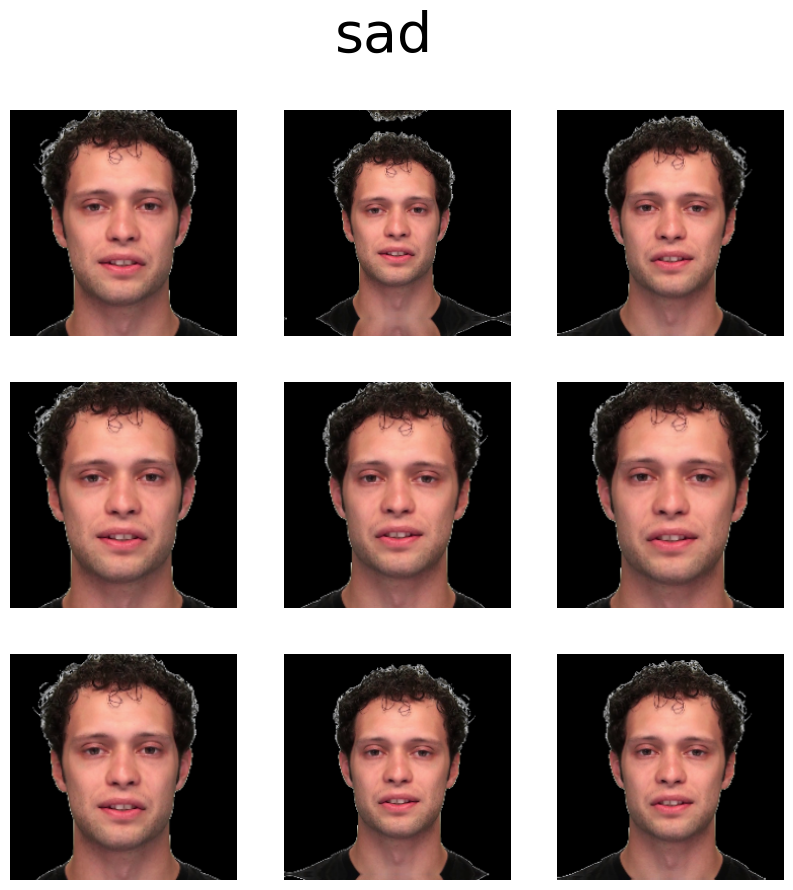

In [154]:
for images, labels in train_ds.take(1):
    fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
    fig.suptitle(emotions[int(labels[0])], fontsize=40)
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0), training=True
        )
        plt.imshow(augmented_image[0], cmap='gray')
        plt.axis("off")

# Net Architecture

In [155]:
# frame_type = ''
epochs = 10
lr = 0.001
momentum = 0.5

In [156]:
from datetime import datetime
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Correct path to save the model
checkpoint_filepath = (
    f'/home/heru/sonamyangchen/ravdess_emotion/Video_model'
    f'{datetime.now().strftime("%d-%m-%y_%H-%M")}_face.keras'
)


# Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor="val_sparse_categorical_accuracy",
    factor=0.5,
    patience=2,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_sparse_categorical_accuracy",
    patience=4,
    verbose=1,
    restore_best_weights=True
)

save_best = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_sparse_categorical_accuracy',
    mode='max',
    save_best_only=True
)

print("Checkpoint will be saved to:", checkpoint_filepath)


Checkpoint will be saved to: /home/heru/sonamyangchen/ravdess_emotion/Video_model21-11-25_11-04_face.keras


In [157]:
pretrained_model = ResNet50(include_top=False,
                            input_shape=(height_orig, width_orig, 3),
                            weights='imagenet',
                            pooling='avg')
pretrained_model.trainable = False


input = Input(shape=(height_orig, width_orig, 3))
x = input
x = data_augmentation(x)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = pretrained_model(x, training=False) # `training=False` important for fine-tuning
x = Dense(512, activation='relu')(x)
x = Dense(num_classes, activation='softmax')(x)
output = x

net_2 = Model(input, output)
net_2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │  1,049,088 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 7)         │      3,591 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,640,391 (94.00 MB)

 Trainable params: 1,052,679 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [158]:
net_2.compile(
    optimizer=Adam(learning_rate=lr),
    # optimizer=keras.optimizers.SGD(learning_rate=learningrate, momentum=momentum)
    loss=sparse_categorical_crossentropy,
    metrics=[sparse_categorical_accuracy, sparse_top_k_categorical_accuracy],
)

In [159]:
history_2 = net_2.fit(train_ds,
                    epochs=epochs,
                    validation_data=val_ds,
                    batch_size=batch_size,
                    steps_per_epoch=step_per_epoch_train,
                    validation_steps=step_per_epoch_val,
                    # callbacks=[reduce_lr, early_stop, save_best],
                    # callbacks=[save_best],
                    verbose=1)

Epoch 1/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 51s 133ms/step - loss: 1.9975 - sparse_categorical_accuracy: 0.1456 - sparse_top_k_categorical_accuracy: 0.7253 - val_loss: 1.9706 - val_sparse_categorical_accuracy: 0.1399 - val_sparse_top_k_categorical_accuracy: 0.7143
Epoch 2/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 49s 137ms/step - loss: 1.9467 - sparse_categorical_accuracy: 0.1612 - sparse_top_k_categorical_accuracy: 0.7496 - val_loss: 1.9421 - val_sparse_categorical_accuracy: 0.1808 - val_sparse_top_k_categorical_accuracy: 0.7414
Epoch 3/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 49s 134ms/step - loss: 1.9272 - sparse_categorical_accuracy: 0.1778 - sparse_top_k_categorical_accuracy: 0.7712 - val_loss: 1.9381 - val_sparse_categorical_accuracy: 0.1555 - val_sparse_top_k_categorical_accuracy: 0.7281
Epoch 4/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 49s 136ms/step - loss: 1.9095 - sparse_categorical_accuracy: 0.1929 - sparse_top_k_categorical_accuracy: 0.8000 - val_loss: 2.0020 - val_sparse_categorical_accuracy: 0.1339 - va

# Evaluation

In [160]:
net_2.evaluate(val_ds,
            batch_size=batch_size,
            steps=step_per_epoch_val)

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 2.1129 - sparse_categorical_accuracy: 0.1791 - sparse_top_k_categorical_accuracy: 0.7880


[2.1162874698638916, 0.1629464328289032, 0.7805059552192688]

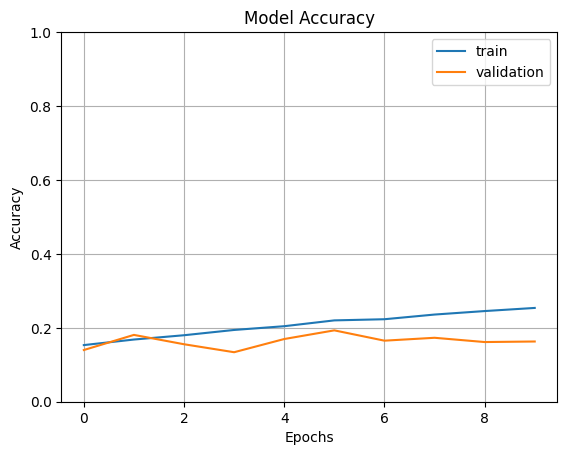

In [161]:
fig1 = plt.gcf()
plt.plot(history_2.history['sparse_categorical_accuracy'])
plt.plot(history_2.history['val_sparse_categorical_accuracy'])
plt.axis(ymin=0, ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
# plt.savefig('Plots/model2_accuracy.png')
plt.show()

In [162]:
from sklearn.metrics import classification_report
y_val = []
y_pred = []
i = 1
for image, target in val_ds:
  if i > step_per_epoch_val:
    break
  y_val.extend(target.numpy())
  y_pred.extend(net_2(image, training=False).numpy().argmax(axis=1))
  i+=1

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.16      0.59      0.25       384
           1       0.70      0.28      0.40       384
           2       0.09      0.22      0.12       384
           3       0.02      0.01      0.01       384
           4       0.43      0.04      0.07       384
           5       0.00      0.00      0.00       384
           6       0.00      0.00      0.00       384

    accuracy                           0.16      2688
   macro avg       0.20      0.16      0.12      2688
weighted avg       0.20      0.16      0.12      2688



/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [163]:
# Directory to save models
save_dir = '/home/heru/sonamyangchen/ravdess_emotion/Video_model/'
os.makedirs(save_dir, exist_ok=True)

# Function to save model with timestamp
def save_model(model, prefix="Video-CNN_model"):
    timestamp = datetime.now().strftime("%d-%m-%y_%H-%M-%S")
    filepath = os.path.join(save_dir, f"{prefix}_{timestamp}_face.keras")
    model.save(filepath)
    print(f"Model saved to: {filepath}")
    return filepath
# Save the trained model
save_model(net_2, prefix="Video-CNN_model2")

Model saved to: /home/heru/sonamyangchen/ravdess_emotion/Video_model/Video-CNN_model2_21-11-25_11-13-19_face.keras


'/home/heru/sonamyangchen/ravdess_emotion/Video_model/Video-CNN_model2_21-11-25_11-13-19_face.keras'

# Model 3: 112x112 BW
Dataset creation

In [164]:
filenames_train = []  # train
filenames_val = []    # validation

for dirpath, dirnames, files in os.walk(path_frames):
    if not files:
        continue  # skip empty folders

    # Try to extract emotion label from the first file
    try:
        class_temp = int(files[0].split('-')[2]) - 1
    except (IndexError, ValueError):
        print(f"⚠ Skipping {dirpath}, unexpected file naming.")
        continue

    if class_temp == 0:  # skip 'neutral' emotion
        continue

    # Create full paths for all frames in this folder
    frame_paths = [os.path.join(dirpath, f) for f in files]
    labels = [emotions_tras[class_temp]] * len(files)

    # Assign to train or validation based on actor ID in folder path
    if any(act in dirpath for act in val_actors):
        filenames_val.append(list(zip(frame_paths, labels)))
    elif not any(act in dirpath for act in test_actors + val_actors):
        filenames_train.append(list(zip(frame_paths, labels)))

# Check counts
print(f"Total training videos: {len(filenames_train)}")
print(f"Total validation videos: {len(filenames_val)}")


⚠ Skipping Datasets/, unexpected file naming.
Total training videos: 3024
Total validation videos: 336


In [165]:
def sampling(list, num_frames_desired):
    tot = []
    for elem in list:
        sampled_list = random.sample(elem, num_frames_desired)
        tot += sampled_list
    return(tot)

def parse_image(filename):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=1)
    image = tf.image.convert_image_dtype(image, dtype=tf.float16)
    image = tf.image.resize_with_crop_or_pad(image, height_orig, width_orig)
    image = tf.image.resize(image, [height_targ, width_targ])
    print('shape frames:', image.shape)
    return image

def configure_for_performance(ds):
    ds = ds.shuffle(buffer_size=1000) # serve?
    ds = ds.batch(batch_size)
    ds = ds.repeat()
    ds = ds.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return ds

def load_dataset(filenames, batch_size):
    frames_per_vid = min([len(elem) for elem in filenames])     # number of frames per clip in order to have balanced classes
    print("frames per video:", frames_per_vid) 

    filenames_sampled = sampling(filenames, frames_per_vid)
    random.shuffle(filenames_sampled)

    zipped = [list(t) for t in zip(*filenames_sampled)]

    names = zipped[0]
    labels = zipped[1]

    names = tf.data.Dataset.from_tensor_slices(names)
    images = names.map(parse_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)

    labels = [elem for elem in labels]
    labels = tf.data.Dataset.from_tensor_slices(labels)

    ds = tf.data.Dataset.zip((images, labels))
    ds = configure_for_performance(ds)

    frame_number = len(filenames_sampled)
    step_per_epoch = frame_number // batch_size
    print('frames number:', frame_number, '\nbatch size:', batch_size, '\nbatch number:', step_per_epoch)
    return ds, step_per_epoch

In [166]:
train_ds, step_per_epoch_train = load_dataset(filenames_train, batch_size)

frames per video: 23
shape frames: (112, 112, 1)
frames number: 69552 
batch size: 64 
batch number: 1086


In [167]:
val_ds, step_per_epoch_val = load_dataset(filenames_val, batch_size)

frames per video: 24
shape frames: (112, 112, 1)
frames number: 8064 
batch size: 64 
batch number: 126


# Augmentation

In [168]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    # RandomCutout(0.4, 0.4, fill_mode="constant", fill_value=0.0, seed=None)
])

(112, 112, 1)


2025-11-21 11:13:37.593866: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(np.float64(-0.5), np.float64(111.5), np.float64(111.5), np.float64(-0.5))

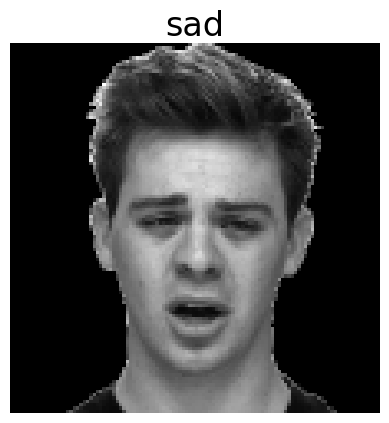

In [169]:
examples = train_ds.unbatch().take(1)

for elem in examples:
    print(elem[0].shape)
plt.imshow(elem[0], cmap='gray')
plt.title(emotions[int(elem[1])], fontdict={'fontsize': 24})
plt.axis('off')
# plt.savefig('Plots/model3_input.png')

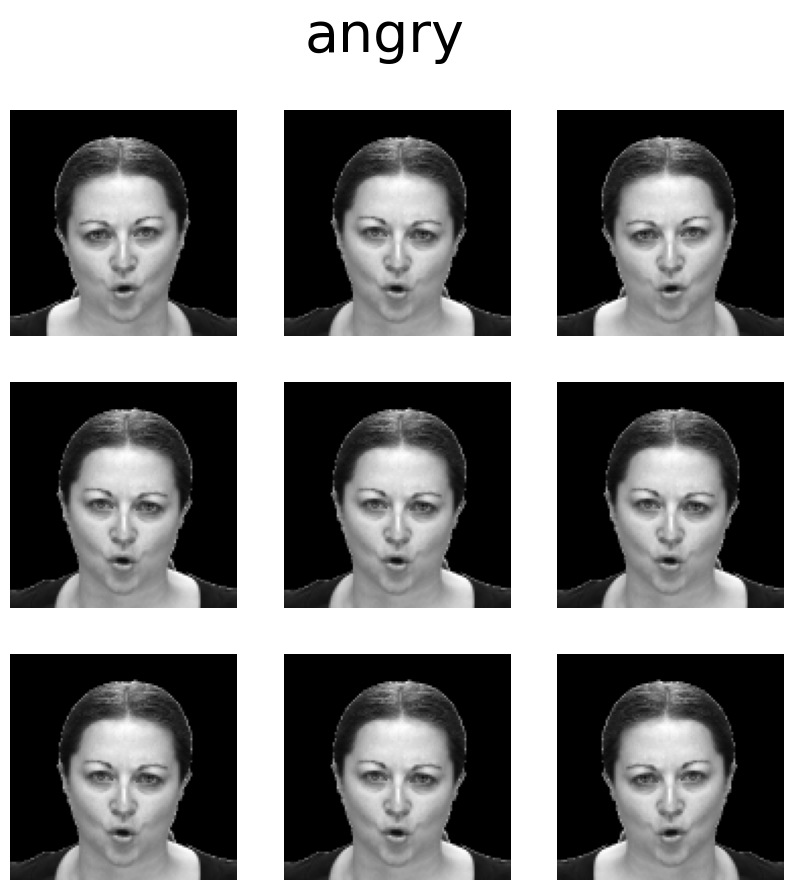

In [170]:
for images, labels in train_ds.take(1):
    fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
    fig.suptitle(emotions[int(labels[0])], fontsize=40)
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0), training=True
        )
        plt.imshow(augmented_image[0], cmap='gray')
        plt.axis("off")

# Net Architecture

In [171]:
# frame_type = ''
epochs = 10
lr = 0.001
momentum = 0.5

In [172]:
input = Input(shape=(width_targ, height_targ, 1))
x = input
x = data_augmentation(x)

x = Conv2D(filters=32, kernel_size=(5,5), padding='same', kernel_initializer='he_normal', name='conv2d_0')(x)
x = BatchNormalization(name='batchnorm_0')(x)
x = Activation('elu')(x)
x = MaxPooling2D(pool_size=(2,2), name='maxpool2d_0')(x)

x = Conv2D(filters=64, kernel_size=(5,5), padding='same', kernel_initializer='he_normal', name='conv2d_1')(x)
x = BatchNormalization(name='batchnorm_1')(x)
x = Activation('elu')(x)
x = MaxPooling2D(pool_size=(2,2), name='maxpool2d_1')(x)

x = Dropout(0.4, name='dropout_1')(x)

x = Conv2D(filters=128, kernel_size=(3,3), padding='same', kernel_initializer='he_normal', name='conv2d_2')(x)
x = BatchNormalization(name='batchnorm_2')(x)
x = Activation('elu')(x)
x = MaxPooling2D(pool_size=(2,2), name='maxpool2d_2')(x)

x = Dropout(0.4, name='dropout_2')(x)

x = Conv2D(filters=256, kernel_size=(3,3), padding='same', kernel_initializer='he_normal', name='conv2d_3')(x)
x = BatchNormalization(name='batchnorm_3')(x)
x = Activation('elu')(x)
x = MaxPooling2D(pool_size=(2,2), name='maxpool2d_3')(x)

x = Dropout(0.5, name='dropout_3')(x)

x = Flatten(name='flatten')(x)
x = Dense(128, kernel_initializer='he_normal', name='dense_1')(x)
x = BatchNormalization(name='batchnorm_4')(x)
x = Activation('elu')(x)

x = Dropout(0.6, name='dropout_4')(x)

x = Dense(num_classes, activation='softmax', name='out_layer')(x)

output = x

net_3 = Model(inputs=input, outputs=output)
net_3.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 112, 112, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 112, 112, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_0 (Conv2D)               │ (None, 112, 112, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_0                     │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_0 (MaxPooling2D)      │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,605,76

 Total params: 2,030,215 (7.74 MB)

 Trainable params: 2,028,999 (7.74 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [173]:
net_3.compile(
        optimizer = Adam(learning_rate=lr),
        # optimizer=keras.optimizers.SGD(learning_rate=learningrate, momentum=momentum)
        loss = sparse_categorical_crossentropy,
        metrics = [sparse_categorical_accuracy],
    )

In [174]:
history_3 = net_3.fit(train_ds,
                    epochs=epochs,
                    validation_data=val_ds,
                    batch_size=batch_size,
                    steps_per_epoch=step_per_epoch_train,
                    validation_steps=step_per_epoch_val,
                    # callbacks=[reduce_lr, early_stop, save_best],
                    # callbacks=[save_best],
                    verbose=1)

Epoch 1/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - loss: 2.0786 - sparse_categorical_accuracy: 0.2697 - val_loss: 2.0700 - val_sparse_categorical_accuracy: 0.3699
Epoch 2/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - loss: 1.1430 - sparse_categorical_accuracy: 0.5779 - val_loss: 1.8940 - val_sparse_categorical_accuracy: 0.4147
Epoch 3/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - loss: 0.8644 - sparse_categorical_accuracy: 0.6889 - val_loss: 1.6909 - val_sparse_categorical_accuracy: 0.4490
Epoch 4/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - loss: 0.7068 - sparse_categorical_accuracy: 0.7480 - val_loss: 1.8000 - val_sparse_categorical_accuracy: 0.5042
Epoch 5/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - loss: 0.5922 - sparse_categorical_accuracy: 0.7906 - val_loss: 1.9651 - val_sparse_categorical_accuracy: 0.4913
Epoch 6/10
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - loss: 0.5307 - sparse_categorical_accuracy: 0.8119 - val_loss: 1.7462 - val_sparse_categoric

In [175]:
net_3.evaluate(val_ds,
            batch_size=batch_size,
            steps=step_per_epoch_val)

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.8268 - sparse_categorical_accuracy: 0.5328


[1.8293206691741943, 0.5272817611694336]

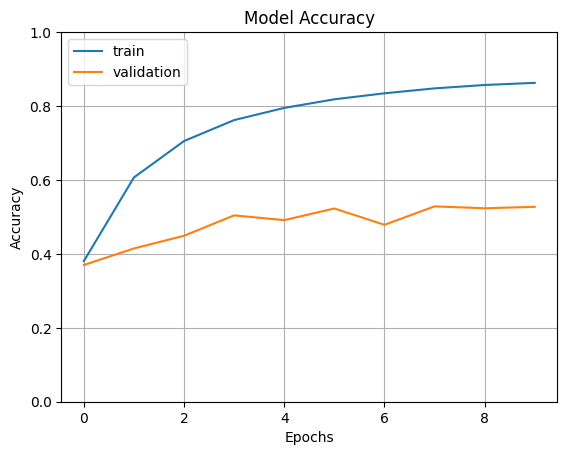

In [176]:
fig1 = plt.gcf()
plt.plot(history_3.history['sparse_categorical_accuracy'])
plt.plot(history_3.history['val_sparse_categorical_accuracy'])
plt.axis(ymin=0, ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
# plt.savefig('Plots/model3_accuracy.png')
plt.show()

In [177]:
from sklearn.metrics import classification_report
y_val = []
y_pred = []
i = 1
for image, target in val_ds:
  if i > step_per_epoch_val:
    break
  y_val.extend(target.numpy())
  y_pred.extend(net_3(image, training=False).numpy().argmax(axis=1))
  i+=1

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.45      0.56      0.50      1152
           1       0.55      0.95      0.70      1152
           2       0.52      0.66      0.58      1152
           3       0.27      0.20      0.23      1152
           4       0.77      0.55      0.64      1152
           5       0.61      0.47      0.53      1152
           6       0.57      0.29      0.38      1152

    accuracy                           0.53      8064
   macro avg       0.53      0.53      0.51      8064
weighted avg       0.53      0.53      0.51      8064



In [178]:
# Directory to save models
save_dir = '/home/heru/sonamyangchen/ravdess_emotion/Video_model/'
os.makedirs(save_dir, exist_ok=True)

# Function to save model with timestamp
def save_model(model, prefix="Video-CNN_model"):
    timestamp = datetime.now().strftime("%d-%m-%y_%H-%M-%S")
    filepath = os.path.join(save_dir, f"{prefix}_{timestamp}_face.keras")
    model.save(filepath)
    print(f"Model saved to: {filepath}")
    return filepath
# Save the trained model
save_model(net_3, prefix="Video-CNN_model3")

Model saved to: /home/heru/sonamyangchen/ravdess_emotion/Video_model/Video-CNN_model3_21-11-25_11-18-56_face.keras


'/home/heru/sonamyangchen/ravdess_emotion/Video_model/Video-CNN_model3_21-11-25_11-18-56_face.keras'